## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import shap
import time, json
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    precision_recall_curve, f1_score, 
    precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

/Users/sahar/miniconda3/envs/py314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Ingestion
- The dataset contains transactions made by credit cards in September 2013 by European cardholders.
- This dataset presents transactions that occurred in __two days__, where we have 492 frauds out of 284,807 transactions. The dataset is highly __unbalanced__, the positive class (frauds) account for 0.172% of all transactions.
- Dataset contains only numerical input variables which are the result of a PCA transformation.
- Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.
- Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset.
- 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning.
- Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

In [2]:
# Add the path to your dataset here
DATA_PATH = Path('//Users/sahar/Documents/Sahar/edu/ml_projects/credit_fraud/Data/creditcard.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "creditcard.csv not found. \n"
        "Download from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()    

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Schema and null check
print("Dtypes:")
print(df.dtypes.to_string())
print(f"\nNull values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Aftre dropping duplicates, {len(df):,} rows")

Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64

Null values: 0
Duplicates: 1081
Aftre dropping duplicates, 283,726 rows


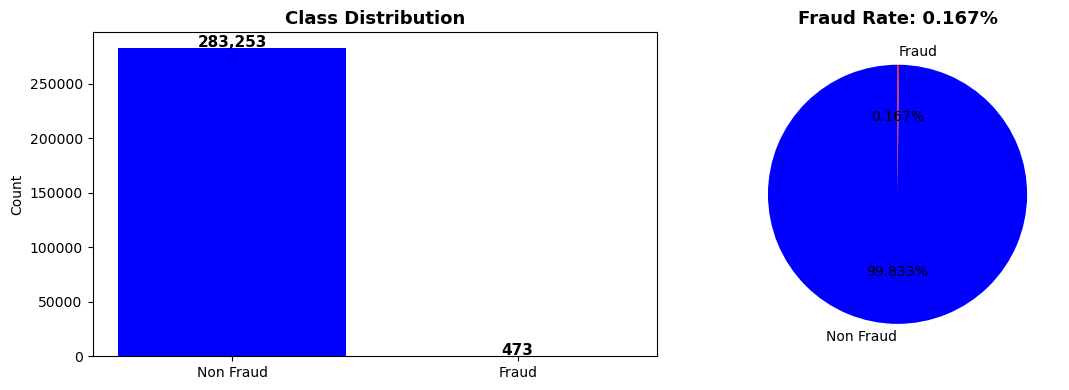


Fraud: 473 (0.167%) | Non Fraud: 283,253


In [8]:
# Class distribution
counts = df["Class"].value_counts()
fraud_rate = df["Class"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Non Fraud", "Fraud"], counts.values, color=["blue", "red"])
axes[0].set_title("Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v+550, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

axes[1].pie(counts.values, labels=["Non Fraud", "Fraud"], colors=["blue", "red"], autopct="%1.3f%%", startangle=90, pctdistance=0.6)
axes[1].set_title(f"Fraud Rate: {fraud_rate:.3f}%", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"\nFraud: {counts[1]:,} ({fraud_rate:.3f}%) | Non Fraud: {counts[0]:,}")

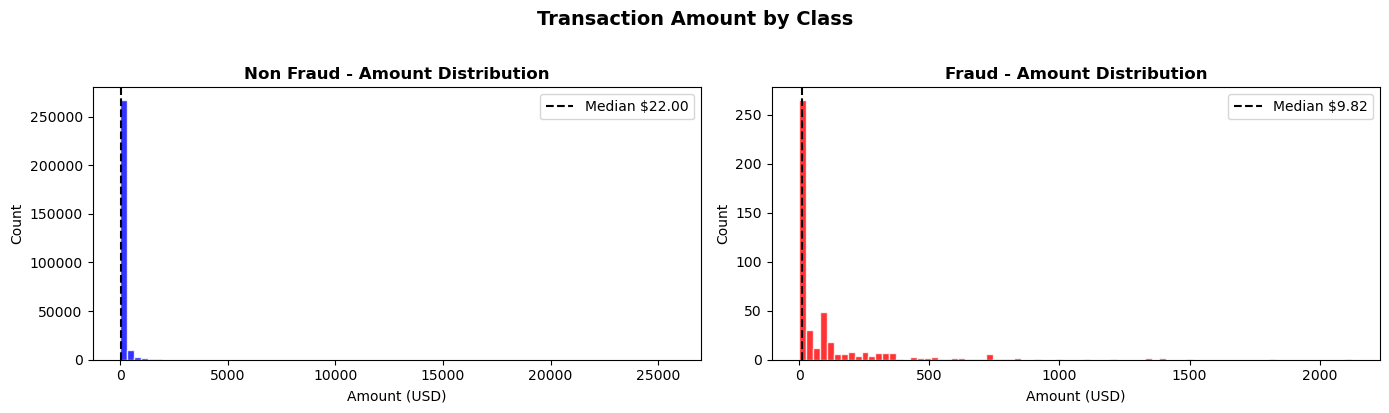

Amount statistics by class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87


In [12]:
# Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, label, color in zip(axes, [0, 1], ["blue", "red"]):
    subset = df[df["Class"] == label]["Amount"] # pandas.series
    name = "Non Fraud" if label == 0 else "Fraud"
    ax.hist(subset, bins=80, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"{name} - Amount Distribution", fontweight="bold")
    ax.set_xlabel("Amount (USD)")
    ax.set_ylabel("Count")
    ax.axvline(subset.median(), color="black", linestyle="dashed", label=f"Median ${subset.median():.2f}")
    ax.legend()

plt.suptitle("Transaction Amount by Class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Amount statistics by class:")
print(df.groupby("Class")["Amount"].describe().round(2))

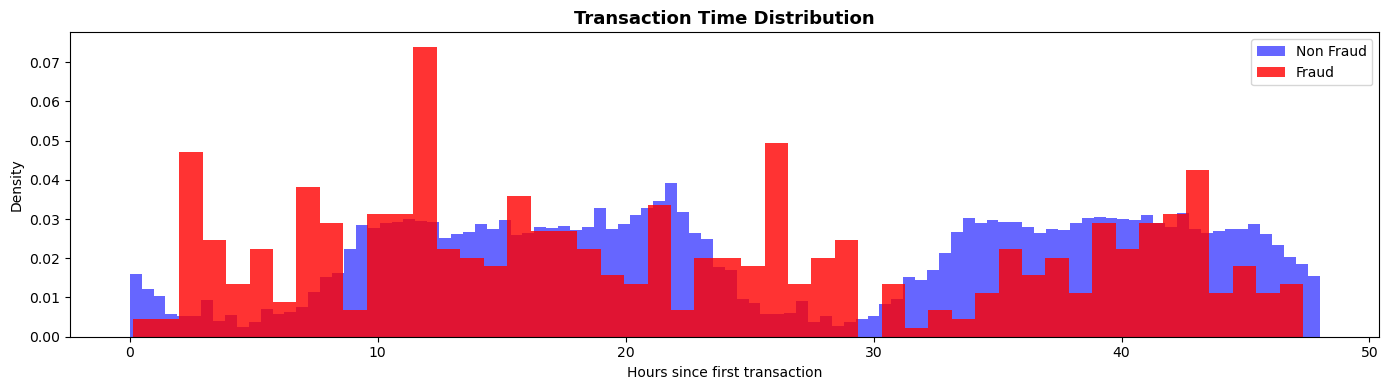

In [13]:
# Time distribution
fig, ax = plt.subplots(figsize=(14, 4))

ax.hist(df[df["Class"] == 0]["Time"]/3600, bins=100, alpha=0.6, color="blue", label="Non Fraud", density=True)
ax.hist(df[df["Class"] == 1]["Time"]/3600, bins=50, alpha=0.8, color="red", label="Fraud", density=True)
ax.set_xlabel("Hours since first transaction")
ax.set_ylabel("Density")
ax.set_title("Transaction Time Distribution", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

## Feature Engineering
V1-V28 are already PCA-transformed. We enrich `Time` and `Amount`.

| Feature | Description |
|---|---|
| `hour_of_day` | Fractional hour within a 24h cycle |
| `hour_sin`, `hour_cos` | Cyclic encoding to avoid midnight discontinuity |
| `is_night` | Flag for hours 22–6 |
| `log_amount` | Log₁₊(Amount) → corrects right skew |
| `amount_bucket` | Quintile bin of Amount |
| `amount_x_hour` | Interaction: log_amount × hour_of_day |
| `tx_velocity_1h` | Rolling transaction count (proxy velocity) |
| `rolling_avg_amount` | Rolling mean amount |

In [14]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values("Time").reset_index(drop=True) # resets the index and drops the old one
    df_timed = df.set_index("Time")

    # Time features
    df["hour_of_day"] = (df["Time"] % 86400) / 3600
    df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)
    df["is_night"] = ((df["hour_of_day"] < 6) | (df["hour_of_day"] >= 22)).astype(int) # True/False to 1/0

    # Amount features
    df["log_amount"] = np.log1p(df["Amount"]) # = np.log(1 + x), handles zero amounts without error
    df["amount_bucket"] = pd.qcut(df["Amount"], q=5, labels=False, duplicates="drop").astype(float) # Relative ranking (low → high)
    df["amount_x_hour"] = df["log_amount"] * df["hour_of_day"]

    # Rolling features (approximate velocity)
    df["tx_velocity_1h"] = (df_timed["Amount"].rolling(window=3600, min_periods=1).count().values)

    df["rolling_avg_amount"] = (df_timed["Amount"].rolling(window=3600, min_periods=1).mean().values)

    return df

df = add_features(df)
engineered_features = ["hour_of_day", "hour_sin", "hour_cos", 
                       "is_night", "log_amount", "amount_bucket", 
                       "amount_x_hour", "tx_velocity_1h", "rolling_avg_amount"]
print(f"Added {len(engineered_features)} features. Total columns: {df.shape[1]}")
df[engineered_features].describe().round(2)

Added 9 features. Total columns: 40


,hour_of_day,hour_sin,hour_cos,is_night,log_amount,amount_bucket,amount_x_hour,tx_velocity_1h,rolling_avg_amount
count,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00
mean,14.54,-0.27,-0.14,0.18,3.15,2.00,45.61,3577.17,88.50
std,5.85,0.63,0.72,0.38,1.66,1.41,30.94,232.96,17.78
min,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,1.00,36.74
25%,10.60,-0.84,-0.84,0.00,1.89,1.00,19.72,3600.00,72.14
50%,15.01,-0.44,-0.31,0.00,3.14,2.00,42.20,3600.00,91.49
75%,19.33,0.25,0.60,0.00,4.36,3.00,65.31,3600.00,104.23
max,24.00,1.00,1.00,1.00,10.15,4.00,225.07,3600.00,176.99


/var/folders/v_/1czwrsjd5554z7_8tbs7r5jh0000gn/T/ipykernel_3982/3179737594.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


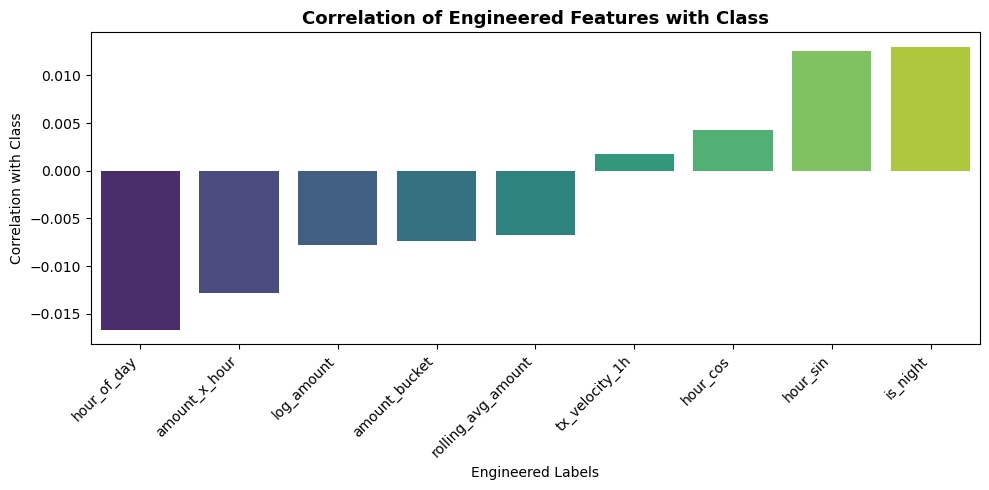

In [17]:
# Correlation of engineered features with Class
corr = df[engineered_features + ["Class"]].corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=corr.index, y=corr.values, palette="viridis", hue=corr.index, ax=ax)
ax.set_title("Correlation of Engineered Features with Class", fontsize=13, fontweight="bold")
ax.set_ylabel("Correlation with Class")
ax.set_xlabel("Engineered Labels")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Preprocessing and Class Imbalance

__Challenges__:
- Severe class imbalance (~0.17% fraud), naive models predict all non-fraud
- `Time` and `Amount` need scaling (V1-V28 are already normalized)

__Strategy__:
- Time-aware split: Train on earlier transactions, test on later ones.
- StandardScaler: Fit on train only, applied to val/test.
- SMOTE (Synthetic Minority Oversampling) on train set only

In [18]:
TARGET = "Class"
FEATURES = [c for c in df.columns if c != TARGET]

# Chronological split
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

In [19]:
def split_xy(frame):
    return frame[FEATURES].values, frame[TARGET].astype(int).values

X_train_raw, y_train = split_xy(train_df)
X_val_raw, y_val = split_xy(val_df)
X_test_raw, y_test = split_xy(test_df)

print(f"Train : {len(y_train):>7,}  Fraud: {y_train.sum():>4} ({y_train.mean()*100:.3f}%)")
print(f"Val   : {len(y_val):>7,}  Fraud: {y_val.sum():>4} ({y_val.mean()*100:.3f}%)")
print(f"Test  : {len(y_test):>7,}  Fraud: {y_test.sum():>4} ({y_test.mean()*100:.3f}%)")

Train : 198,608  Fraud:  366 (0.184%)
Val   :  42,559  Fraud:   55 (0.129%)
Test  :  42,559  Fraud:   52 (0.122%)


In [20]:
# Scaling
SCALE_COLS = ["Time", "Amount", "log_amount", "hour_of_day", "hour_sin", "hour_cos", 
              "amount_x_hour", "tx_velocity_1h", "rolling_avg_amount"]
scale_idx = [FEATURES.index(col) for col in SCALE_COLS]

scaler = StandardScaler()
X_train_raw[:, scale_idx] = scaler.fit_transform(X_train_raw[:, scale_idx])
X_val_raw[:, scale_idx] = scaler.transform(X_val_raw[:, scale_idx])
X_test_raw[:, scale_idx] = scaler.transform(X_test_raw[:, scale_idx])

print("Scaling applied to: ", [FEATURES[i] for i in scale_idx])

Scaling applied to:  ['Time', 'Amount', 'log_amount', 'hour_of_day', 'hour_sin', 'hour_cos', 'amount_x_hour', 'tx_velocity_1h', 'rolling_avg_amount']


In [21]:
# SMOTE
smote_ratio = 0.10 # target: fraud = 10% of legitimate after oversampling

n_legit = (y_train == 0).sum()
target_n_fraud = int(n_legit * smote_ratio)
print(f"Before SMOTE: fraud={y_train.sum():,} / total={len(y_train):,}")

smote = SMOTE(sampling_strategy={1: target_n_fraud}, random_state=SEED)
X_train, y_train_s = smote.fit_resample(X_train_raw, y_train)
X_val, y_val_s = X_val_raw, y_val
X_test, y_test_s = X_test_raw, y_test

print(f"After SMOTE : fraud={y_train_s.sum():,} / total={len(y_train_s):,}  "
      f"({y_train_s.mean()*100:.1f}% fraud rate)")

Before SMOTE: fraud=366 / total=198,608
After SMOTE : fraud=19,824 / total=218,066  (9.1% fraud rate)


## Model Training

| Model | Rationale |
|---|---|
| **Logistic Regression** | Interpretable baseline; fast; calibrated probabilities |
| **Random Forest** | Robust ensemble; OOB score; good feature importance |
| **XGBoost** | Primary model; handles imbalance via `scale_pos_weight`; best PR-AUC |

In [22]:
# Fraud-to-NonFraud ratio for XGBoost weight
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"XGBoost scale_pos_weight: {pos_weight:.1f}")

XGBoost scale_pos_weight: 541.6


In [23]:
models = {
    "Logistic Regression": LogisticRegression(
        C=0.01, max_iter=1000, class_weight="balanced",
        solver="lbfgs", random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        n_jobs=-1, oob_score=True, random_state=SEED
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric="aucpr", use_label_encoder=False,
        tree_method="hist", n_jobs=-1, random_state=SEED,
        verbosity=0
    ),
}

trained = {}
for name, model in models.items():
    t0 = time.time()
    if name == "XGBoost":
        model.fit(X_train, y_train_s,
                  eval_set=[(X_val, y_val_s)], verbose=False)
    else:
        model.fit(X_train, y_train_s)
    elapsed = time.time() - t0
    trained[name] = model
    extra = f" | OOB: {model.oob_score_:.4f}" if hasattr(model, "oob_score_") else ""
    print(f"[{name}] trained in {elapsed:.1f}s{extra}")

[Logistic Regression] trained in 0.8s
[Random Forest] trained in 32.5s | OOB: 0.9996
[XGBoost] trained in 3.1s


## Evaluation
With extreme class imbalance, ROC-AUC can be misleadingly high even for poor models. Precision-Recall AUC (average precision) directly measures performance on the minority class.

**Cost-sensitive analysis:**  
- False Negative (missed fraud): ~$120 average loss  
- False Positive (blocked legit): ~$5 customer friction cost

In [24]:
def evaluate(y_true, y_proba, name="model", threshold=0.5,
             cost_fn=120.0, cost_fp=5.0):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    fp_rate = fp / max(fp + tn, 1)

    fraud_saved = tp * cost_fn
    cost_of_fp = fp * cost_fp
    net_savings = fraud_saved - cost_of_fp

    return {
        "model": name, "threshold": round(threshold, 4),
        "roc_auc": round(roc_auc, 4), "pr_auc": round(pr_auc, 4),
        "f1": round(f1, 4), "precision": round(prec, 4), "recall": round(rec, 4),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "fp_rate": round(fp_rate, 4),
        "net_savings_usd": round(net_savings, 2),
    }

In [25]:
# Evaluate all models on validation set
val_results = {}
for name, model in trained.items():
    proba = model.predict_proba(X_val)[:, 1]
    val_results[name] = evaluate(y_val_s, proba, name=name)

val_df_result = pd.DataFrame(val_results.values())
display_cols = ["model","roc_auc","pr_auc","f1","precision","recall","fp_rate"]
print("=== Validation Set Results ===")
val_df_result[display_cols].set_index("model")

=== Validation Set Results ===


,roc_auc,pr_auc,f1,precision,recall,fp_rate
model,,,,,,
Logistic Regression,0.9815,0.8494,0.0568,0.0293,0.9273,0.0397
Random Forest,0.9786,0.8405,0.8660,1.0000,0.7636,0.0000
XGBoost,0.9797,0.7616,0.3271,0.2056,0.8000,0.0040


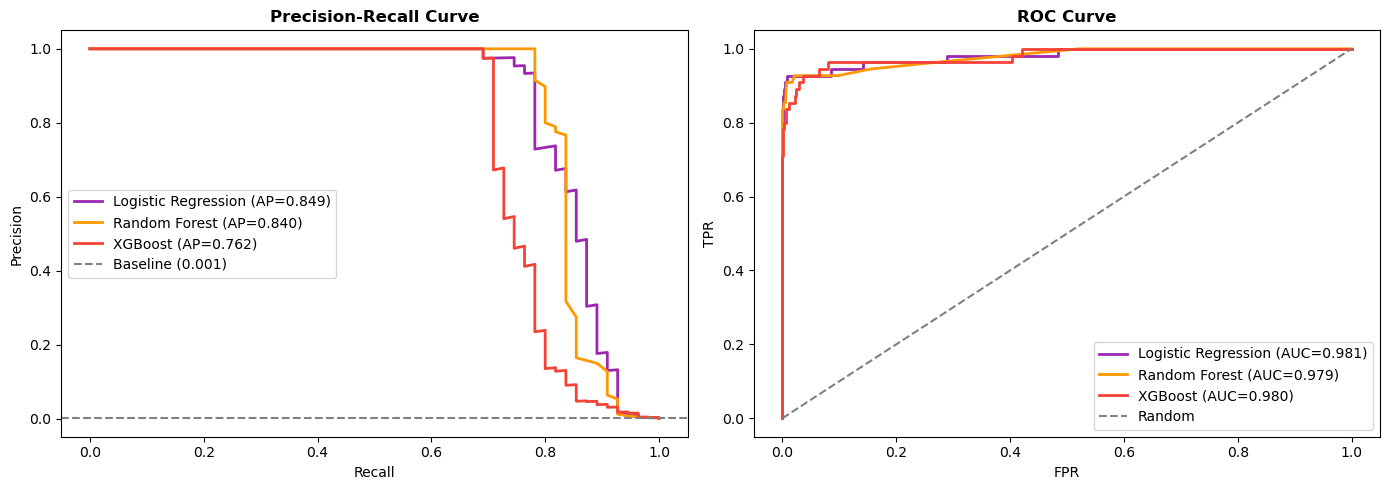

In [26]:
# PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Logistic Regression": "#9C27B0",
          "Random Forest":       "#FF9800",
          "XGBoost":             "#F44336"}

for name, model in trained.items():
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val_s, proba)
    ap = average_precision_score(y_val_s, proba)
    axes[0].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=colors[name], lw=2)

    fpr_arr = np.linspace(0, 1, 300)
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_val_s, proba)
    auc = roc_auc_score(y_val_s, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=colors[name], lw=2)

baseline = y_val_s.mean()
axes[0].axhline(baseline, ls="--", color="gray", label=f"Baseline ({baseline:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve", fontweight="bold")
axes[0].legend()

axes[1].plot([0,1],[0,1], ls="--", color="gray", label="Random")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

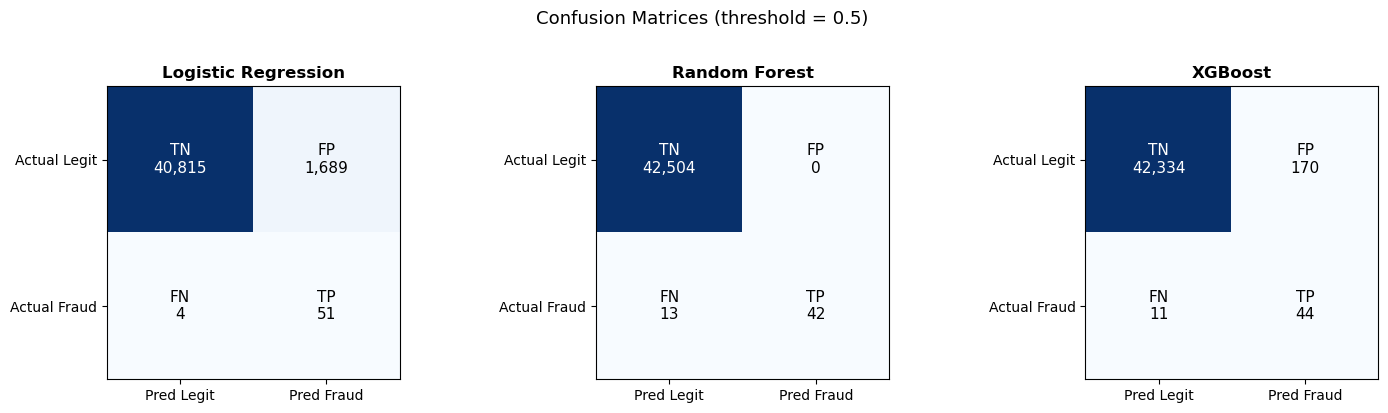

In [27]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, trained.items()):
    proba = model.predict_proba(X_val)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_val_s, y_pred)
    tn, fp, fn, tp = cm.ravel()

    im = ax.imshow(cm, cmap="Blues")
    labels = [["TN", "FP"], ["FN", "TP"]]
    vals = [[tn, fp], [fn, tp]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{vals[i][j]:,}", ha="center", va="center",
                    fontsize=11, color="white" if vals[i][j] > cm.max()/2 else "black")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred Legit","Pred Fraud"])
    ax.set_yticklabels(["Actual Legit","Actual Fraud"])
    ax.set_title(name, fontweight="bold")

plt.suptitle("Confusion Matrices (threshold = 0.5)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Threshold Optimization
The default 0.5 threshold is arbitrary for imbalanced fraud data. We sweep all thresholds from the precision-recall curve and select the one that **maximises F1** on the validation set.

In [28]:
def find_best_threshold(y_true, y_proba, metric="f1"):
    _, _, thresholds = precision_recall_curve(y_true, y_proba)
    best_t, best_score = 0.5, -np.inf
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score, best_t = score, float(t)
    return best_t, best_score

In [29]:
optimal_thresholds = {}
for name, model in trained.items():
    proba = model.predict_proba(X_val)[:, 1]
    t, score = find_best_threshold(y_val_s, proba)
    optimal_thresholds[name] = t
    print(f"{name:<25} optimal threshold: {t:.4f}  (val F1={score:.4f})")

Logistic Regression       optimal threshold: 1.0000  (val F1=0.8515)
Random Forest             optimal threshold: 0.4750  (val F1=0.8776)
XGBoost                   optimal threshold: 0.9991  (val F1=0.8211)


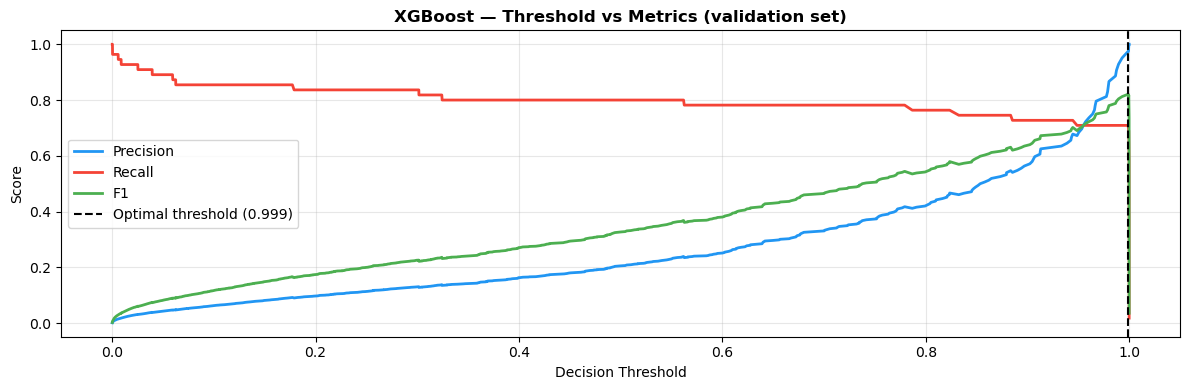

In [31]:
# Threshold vs F1/Precision/Recall curve for XGBoost
xgb_proba = trained["XGBoost"].predict_proba(X_val)[:, 1]
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_val_s, xgb_proba)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(thr_arr, prec_arr[:-1], label="Precision", color="#2196F3", lw=2) # prec_arr[:-1] drops the last element which corresponds to threshold=1.0
ax.plot(thr_arr, rec_arr[:-1],  label="Recall",    color="#F44336",  lw=2)
ax.plot(thr_arr, f1_arr,        label="F1",        color="#4CAF50",  lw=2)
best_t = optimal_thresholds["XGBoost"]
ax.axvline(best_t, color="black", ls="--", label=f"Optimal threshold ({best_t:.3f})")
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Score")
ax.set_title("XGBoost — Threshold vs Metrics (validation set)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Final test-set evaluation with optimal thresholds
test_results = []
for name, model in trained.items():
    proba = model.predict_proba(X_test)[:, 1]
    t = optimal_thresholds[name]
    res = evaluate(y_test_s, proba, name=name, threshold=t)
    test_results.append(res)

test_df_result = pd.DataFrame(test_results)
print("=== Test Set Results (optimal thresholds) ===")
cols = ["model","threshold","roc_auc","pr_auc","f1","precision","recall","net_savings_usd"]
test_df_result[cols].set_index("model")

=== Test Set Results (optimal thresholds) ===


,threshold,roc_auc,pr_auc,f1,precision,recall,net_savings_usd
model,,,,,,,
Logistic Regression,1.0000,0.9801,0.6984,0.7865,0.9459,0.6731,4190.0
Random Forest,0.4750,0.9638,0.7592,0.8352,0.9744,0.7308,4555.0
XGBoost,0.9991,0.9325,0.7403,0.7692,0.8974,0.6731,4180.0


## Explainability (SHAP)
__SHAP (SHapley Additive exPlanations)__ assigns each feature a contribution score for each prediction.
- **Global**: Which features matter most on average?  
- **Local**: Why was *this specific transaction* flagged?

In [34]:
# Fit SHAP TreeExplainer on XGBoost (best model)
xgb_model = trained["XGBoost"]

explainer = shap.TreeExplainer(xgb_model)
#n_shap_test = min(500, len(X_test))
n_shap_test = len(X_test)
idx_sample = np.random.choice(len(X_test), n_shap_test, replace=False)
X_test_sample = X_test[idx_sample]

print(f"Computing SHAP values for {n_shap_test} test samples …")
shap_values = explainer.shap_values(X_test_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print(f"SHAP values shape: {shap_values.shape}")

Computing SHAP values for 42559 test samples …
SHAP values shape: (42559, 39)


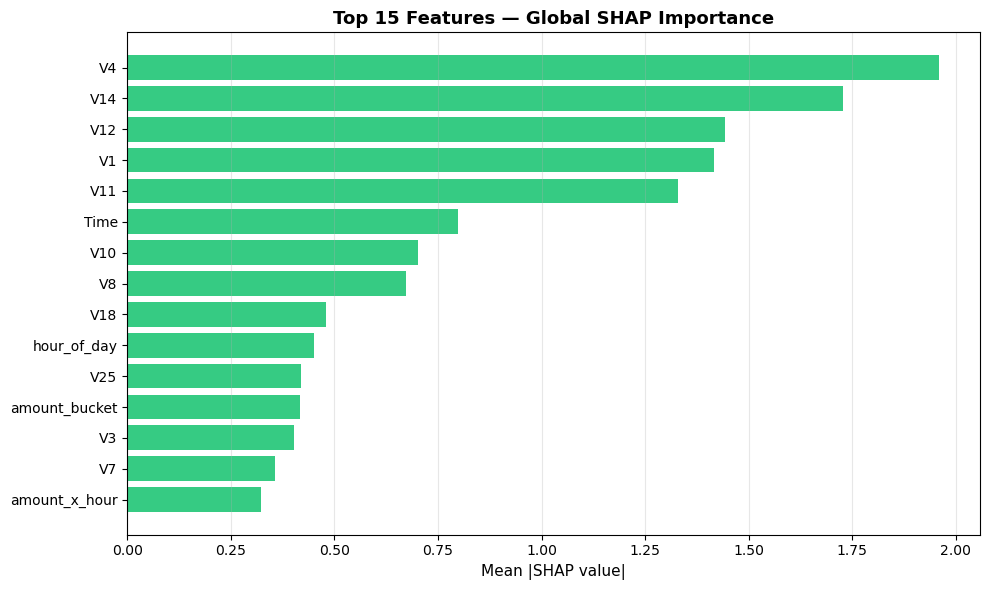


Top 5 most important features:
feature  mean_abs_shap
     V4       1.960409
    V14       1.727627
    V12       1.441954
     V1       1.417414
    V11       1.330404


In [36]:
# Global feature importance (mean |SHAP|)
mean_abs = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs})
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df["feature"][::-1], importance_df["mean_abs_shap"][::-1],
               color="#13C26D", alpha=0.85)
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title("Top 15 Features — Global SHAP Importance", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
print("\nTop 5 most important features:")
print(importance_df.head(5).to_string(index=False))

/var/folders/v_/1czwrsjd5554z7_8tbs7r5jh0000gn/T/ipykernel_3982/1728105531.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


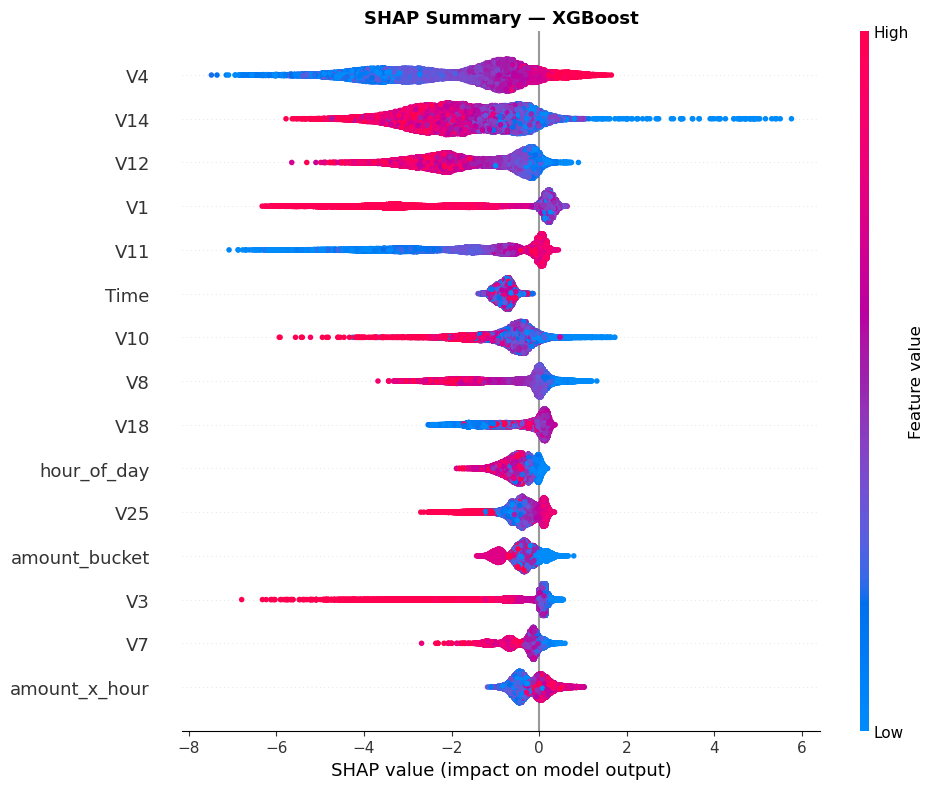

In [37]:
# SHAP summary beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_sample,
    feature_names=FEATURES,
    max_display=15,
    show=False,
    plot_size=None,
)
plt.title("SHAP Summary — XGBoost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Most suspicious transaction (index 10034)
  Fraud probability : 1.0000
  True label        : Fraud


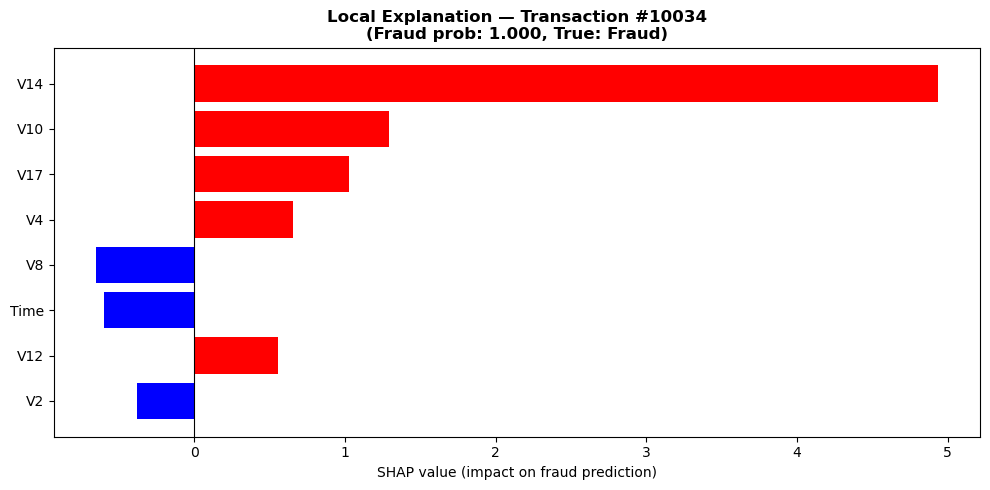

In [39]:
# Local explanation: most confident fraud prediction
xgb_proba_test = trained["XGBoost"].predict_proba(X_test)[:, 1]
most_fraud_idx = int(np.argmax(xgb_proba_test))

print(f"Most suspicious transaction (index {most_fraud_idx})")
print(f"  Fraud probability : {xgb_proba_test[most_fraud_idx]:.4f}")
print(f"  True label        : {'Fraud' if y_test_s[most_fraud_idx] == 1 else 'Legitimate'}")

# SHAP waterfall for this transaction
sample_idx_in_sample = None
for i, idx in enumerate(idx_sample):
    if idx == most_fraud_idx:
        sample_idx_in_sample = i
        break

if sample_idx_in_sample is not None:
    sv = shap_values[sample_idx_in_sample]
    top_k = 8
    top_feat_idx = np.argsort(np.abs(sv))[-top_k:][::-1]
    top_feats = [FEATURES[i] for i in top_feat_idx]
    top_vals = sv[top_feat_idx]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["red" if v > 0 else "blue" for v in top_vals]
    ax.barh(top_feats[::-1], top_vals[::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP value (impact on fraud prediction)")
    ax.set_title(f"Local Explanation — Transaction #{most_fraud_idx}\n"
                 f"(Fraud prob: {xgb_proba_test[most_fraud_idx]:.3f}, "
                 f"True: {'Fraud' if y_test_s[most_fraud_idx]==1 else 'Legit'})",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Transaction not in SHAP sample. Re-run with larger n_shap_test.")

## 8 · Monitoring & Drift Detection

**Population Stability Index (PSI)** measures how much a distribution has shifted:

| PSI | Interpretation |
|---|---|
| < 0.10 | Stable — no action needed |
| 0.10 – 0.25 | Moderate shift — monitor closely |
| > 0.25 | Significant drift — consider retraining |

In [40]:
def compute_psi(reference: np.ndarray, current: np.ndarray, n_bins: int = 10) -> float:
    ref_counts, bin_edges = np.histogram(reference, bins=n_bins)
    cur_counts, _ = np.histogram(current, bins=bin_edges)
    ref_pct = (ref_counts + 1e-6) / (len(reference) + n_bins * 1e-6)
    cur_pct = (cur_counts + 1e-6) / (len(current)   + n_bins * 1e-6)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

# Compute PSI for each feature: val (reference) vs test (current)
psi_records = []
for i, feat in enumerate(FEATURES):
    psi = compute_psi(X_val[:, i], X_test[:, i])
    psi_records.append({"feature": feat, "psi": round(psi, 4),
                         "status": "DRIFT" if psi > 0.25
                                   else ("WATCH" if psi > 0.10 else "OK")})

psi_df = pd.DataFrame(psi_records).sort_values("psi", ascending=False)
print(f"Features with drift (PSI > 0.25): {(psi_df['status']=='DRIFT').sum()}")
print(f"Features to watch (PSI > 0.10):   {(psi_df['status']=='WATCH').sum()}")
psi_df.head(10)

Features with drift (PSI > 0.25): 4
Features to watch (PSI > 0.10):   1


,feature,psi,status
32,hour_cos,21.2270,DRIFT
0,Time,20.7861,DRIFT
30,hour_of_day,20.7861,DRIFT
38,rolling_avg_amount,16.2190,DRIFT
36,amount_x_hour,0.2493,WATCH
33,is_night,0.0814,OK
34,log_amount,0.0354,OK
35,amount_bucket,0.0331,OK
2,V2,0.0167,OK
31,hour_sin,0.0160,OK


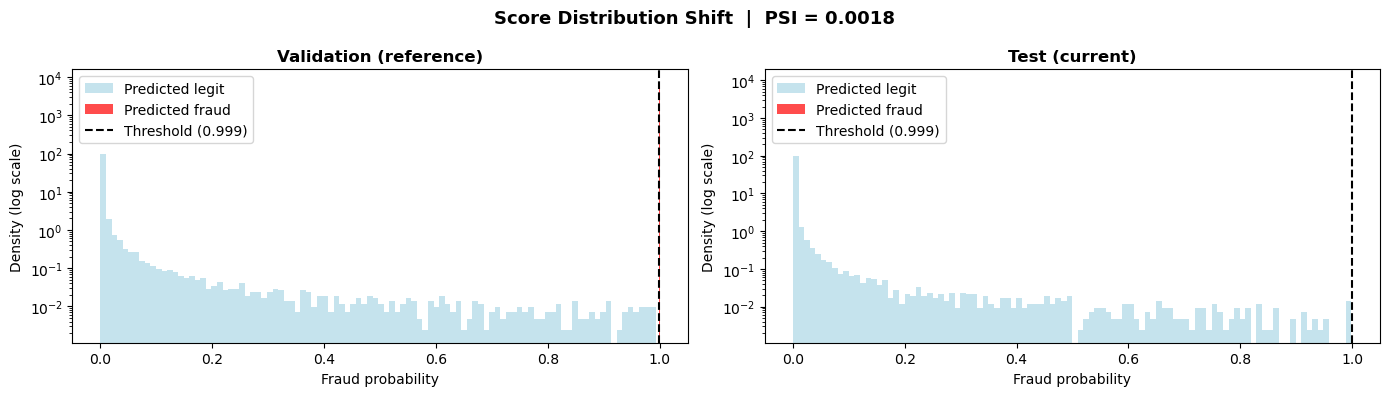

Score PSI: 0.0018 — STABLE


In [42]:
# Score distribution: val vs test 
val_scores  = trained["XGBoost"].predict_proba(X_val)[:, 1]
test_scores = trained["XGBoost"].predict_proba(X_test)[:, 1]
score_psi   = compute_psi(val_scores, test_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
threshold  = optimal_thresholds["XGBoost"]

for ax, scores, label in zip(axes, [val_scores, test_scores], ["Validation (reference)", "Test (current)"]):
    ax.hist(scores[scores < threshold],  bins=100, color="lightblue", alpha=0.7, density=True, log=True, label="Predicted legit")
    ax.hist(scores[scores >= threshold], bins=8, color="red", alpha=0.7, density=True, log=True, label="Predicted fraud")
    ax.axvline(threshold, color="black", ls="--", label=f"Threshold ({threshold:.3f})")
    ax.set_xlabel("Fraud probability")
    ax.set_ylabel("Density (log scale)")
    ax.set_title(label, fontweight="bold")
    ax.legend()

plt.suptitle(f"Score Distribution Shift  |  PSI = {score_psi:.4f}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Score PSI: {score_psi:.4f} — {'STABLE' if score_psi < 0.10 else 'WATCH' if score_psi < 0.25 else 'DRIFT'}")

## 9 · Feedback Loop & Active Learning

__Active learning__ selects the most uncertain transactions for analyst review. Those with scores near the decision threshold carry the most information for improving the model.

__Feedback signals:__
- Analyst labels (review queue decisions)
- Chargeback signals (definitive fraud confirmation, delayed)

In [43]:
def select_for_review(scores, n=30, threshold=0.5, margin=0.15):
    df_al = pd.DataFrame({
        "idx": np.arange(len(scores)),
        "fraud_probability": scores,
        "uncertainty": 1 - np.abs(scores - threshold) / (threshold + 1e-9),
        "in_margin": (scores >= threshold - margin) & (scores <= threshold + margin),
    })
    uncertain = df_al[df_al["in_margin"]].sort_values("uncertainty", ascending=False)
    high_risk = df_al[~df_al["in_margin"] & (df_al["fraud_probability"] > 0.85)].sort_values(
        "fraud_probability", ascending=False)
    selected = pd.concat([uncertain.head(n//2), high_risk.head(n//2)]).head(n)
    selected["action"] = selected["fraud_probability"].apply(
        lambda p: "block" if p > 0.85 else ("review" if p > threshold - margin else "allow"))
    return selected.reset_index(drop=True)

review_queue = select_for_review(xgb_proba_test, n=20,
                                  threshold=optimal_thresholds["XGBoost"])
print(f"Selected {len(review_queue)} transactions for analyst review:")
print(f"  In uncertainty margin : {review_queue['in_margin'].sum()}")
print(f"  High-risk (>0.85)     : {(review_queue['fraud_probability']>0.85).sum()}")
review_queue[["idx","fraud_probability","uncertainty","action"]].head(10)

Selected 10 transactions for analyst review:
  In uncertainty margin : 10
  High-risk (>0.85)     : 10


,idx,fraud_probability,uncertainty,action
0,19345,0.999276,0.999815,block
1,24294,0.999288,0.999803,block
2,32275,0.998819,0.999727,block
3,33864,0.999515,0.999576,block
4,37923,0.999753,0.999338,block
5,32282,0.998369,0.999277,block
6,16283,0.999874,0.999217,block
7,18931,0.999885,0.999206,block
8,37929,0.999892,0.999199,block
9,25617,0.999935,0.999156,block


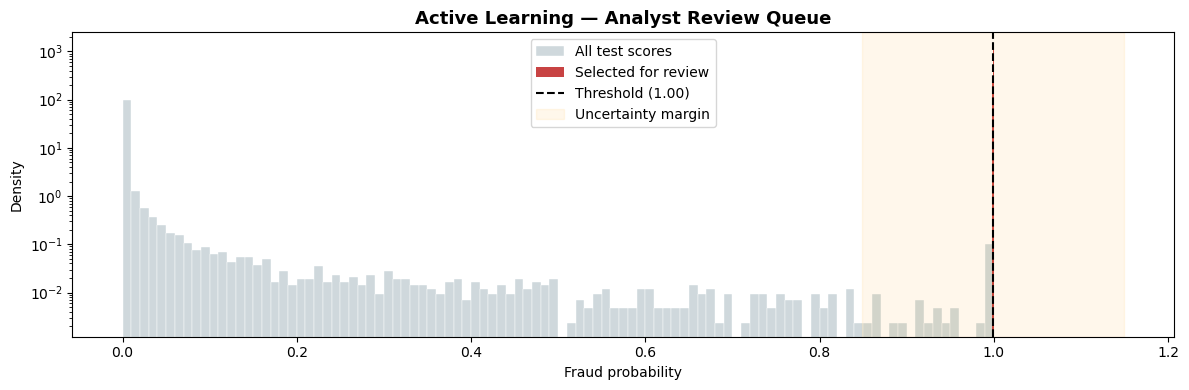

In [44]:
# Visualise review queue 
fig, ax = plt.subplots(figsize=(12, 4))
t = optimal_thresholds["XGBoost"]

ax.hist(xgb_proba_test, bins=100, color="#CFD8DC", edgecolor="white",
        linewidth=0.3, density=True, log=True, label="All test scores")
ax.hist(review_queue["fraud_probability"], bins=4, color="#BB1414",
        alpha=0.8, density=True, log=True, label="Selected for review")
ax.axvline(t, color="black", ls="--", linewidth=1.5, label=f"Threshold ({t:.2f})")
ax.axvspan(t - 0.15, t + 0.15, alpha=0.08, color="orange", label="Uncertainty margin")
ax.set_xlabel("Fraud probability"); ax.set_ylabel("Density")
ax.set_title("Active Learning — Analyst Review Queue", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

## Key takeaways

- **XGBoost** achieves the highest PR-AUC (The most meaningful metric for imbalanced fraud detection)
- **SMOTE** oversampling on the training set dramatically improves recall without contaminating val/test
- **Optimal threshold** (maximising F1 on val set) outperforms the default 0.5 cutoff, increasing fraud capture while controlling false positives
- **SHAP** reveals that V14, V17, and V12 are the most discriminative PCA components (consistent with published literature on this dataset)
- **PSI monitoring** provides an early warning system before model performance degrades in production

In [45]:
# Final model comparison table
summary = pd.DataFrame(test_results)[
    ["model","threshold","roc_auc","pr_auc","f1","precision","recall",
     "tp","fp","fn","net_savings_usd"]
].set_index("model")
print("=== Final Test Set Results ===")
summary

=== Final Test Set Results ===


,threshold,roc_auc,pr_auc,f1,precision,recall,tp,fp,fn,net_savings_usd
model,,,,,,,,,,
Logistic Regression,1.0000,0.9801,0.6984,0.7865,0.9459,0.6731,35,2,17,4190.0
Random Forest,0.4750,0.9638,0.7592,0.8352,0.9744,0.7308,38,1,14,4555.0
XGBoost,0.9991,0.9325,0.7403,0.7692,0.8974,0.6731,35,4,17,4180.0
